In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from unsflow.utils.plot_styles import *

In [4]:
inputFiles = [
    '../rotating_stall_case/results/unstable.pkl',
    '../surge_case/results/unstable.pkl',
    ]

B = [0.5, 1.3]

inputData = []
for inputFile in inputFiles:
    with open(inputFile, 'rb') as f:
        inputData.append(pickle.load(f))


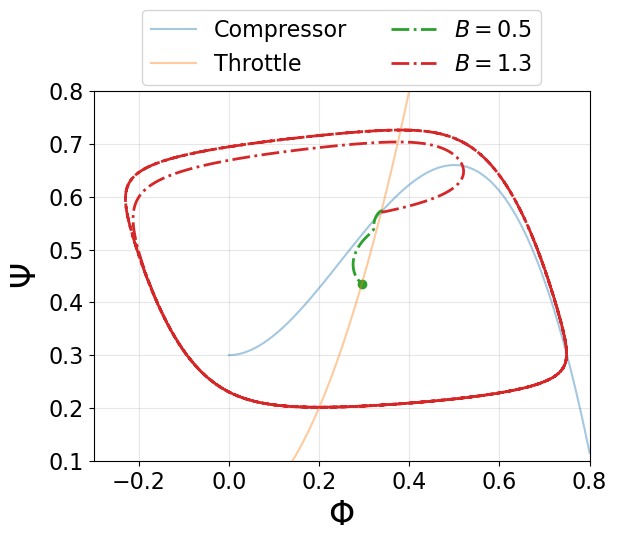

In [5]:
ls = ['--','-.']
plt.figure()
for ii,data in enumerate(inputData):
    if ii==0:
        phi = data.phi
        psi_c = data.psi_c
        psi_v = data.psi_v
        plt.plot(phi, psi_c, label='Compressor', alpha=0.4)
        plt.plot(phi, psi_v, label='Throttle', alpha=0.4)
    
    # transients
    solution = data.solutionMooreGreitzer
    plt.plot(solution[:,1], solution[:,0], '-.', label=r'$B=%.1f$' % B[ii], lw=2, mfc='none')
    if ii==0:
        plt.scatter(solution[-1,1], solution[-1,0], c='C2')
        
    # plt.plot(data['phi_sol'], data['psi_sol'], ls[ii],label=r'$B=%.1f$' % data['B'])
plt.xlabel(r'$\Phi$')
plt.ylabel(r'$\Psi$')
plt.legend(ncol=2, bbox_to_anchor=(0.5, 1.25), loc='upper center')
# plt.tight_layout()
plt.grid(alpha=0.3)
plt.xlim([-0.3,0.8])
plt.ylim([0.1,0.8])
plt.savefig('mooreGreitzer_trajectory_B_0.5_1.0_superposed.pdf', bbox_inches='tight')

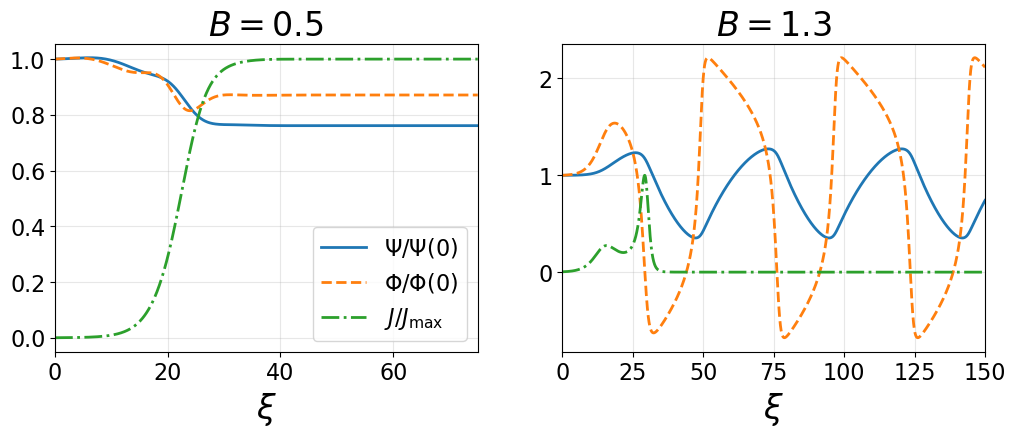

In [6]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

for ii,data in enumerate(inputData):
    sol = data.solutionMooreGreitzer
    xi = data.xi
    # axes[ii].plot(xi, sol[:,0], '-', label=r'$\Psi$')
    # axes[ii].plot(xi, sol[:,1], '--',label=r'$\Phi$')
    # axes[ii].plot(xi, sol[:,2]/np.max(sol[:,2]), '-.',label=r'$J/J_{\rm max}$')
    
    axes[ii].plot(xi, sol[:,0]/sol[0,0], '-', label=r'$\Psi/\Psi(0)$', lw=2)
    axes[ii].plot(xi, sol[:,1]/sol[0,1], '--',label=r'$\Phi/\Phi(0)$', lw=2)
    axes[ii].plot(xi, sol[:,2]/np.max(sol[:,2]), '-.',label=r'$J/J_{\rm max}$', lw=2)

for i,ax in enumerate(axes):
    ax.grid(alpha=0.3)
    ax.set_xlabel(r'$\xi$')
    ax.set_title(r'$B=%.1f$' % B[i])
axes[0].set_xlim([0,75])
axes[1].set_xlim([0,150])
axes[0].legend()
plt.savefig('mooreGreitzer_timeEvolution_B_together_0.5_1.0.pdf', bbox_inches='tight')